<a href="https://colab.research.google.com/github/natnakirs/ML-for-thermal-engineers/blob/main/notebooks/02_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Thermal Engineers
## Lesson 2: Gradient Descent

Author: Srikantan Natarajan

# 1. Problem Motivation

In the previous lesson, linear regression was used to learn a relationship between ambient temperature and compressor power.

But an important question remains:

How does the model actually learn the best values of the slope and intercept?

This lesson introduces **gradient descent**, the optimization process that allows a model to improve its parameters step by step.

# 2. Mathematical Intuition

For linear regression, the model predicts:

$$
\hat{y} = wx + b
$$

Where:

- $x$ = input variable  
- $\hat{y}$ = predicted output  
- $w$ = slope  
- $b$ = intercept  

The model compares the prediction $\hat{y}$ with the actual measured output $y$.

A common loss function is **Mean Squared Error (MSE)**:

$$
MSE = \frac{1}{n} \sum (y - \hat{y})^2
$$

The goal of learning is to find values of $w$ and $b$ that minimize this error.

Gradient descent updates the parameters using:

$$
w_{new} = w - \alpha \frac{\partial Loss}{\partial w}
$$

$$
b_{new} = b - \alpha \frac{\partial Loss}{\partial b}
$$

where $\alpha$ is the **learning rate**.

# 3. Engineering Analogy

Gradient descent feels very similar to parameter tuning in engineering.

For a thermal systems engineer, a helpful analogy is **PID tuning**:

- Start with an initial guess
- Observe the response
- Adjust the parameters
- Repeat until performance improves

If the adjustment is too small, learning is slow.

If the adjustment is too large, the system becomes unstable.

This is exactly what happens in gradient descent when choosing the learning rate.

# 4. Python Implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
x_raw = np.array([25, 30, 35, 40], dtype=float)
y = np.array([1.5, 2.1, 2.8, 3.6], dtype=float)

# Normalize x for better convergence
x_mean = np.mean(x_raw)
x_std = np.std(x_raw)
x = (x_raw - x_mean) / x_std

# Initialize parameters
w = 0.0
b = 0.0

learning_rate = 0.01
epochs = 5000
n = len(x)

loss_history = []

for i in range(epochs):
    y_pred = w * x + b

    # Mean squared error
    loss = np.mean((y - y_pred) ** 2)
    loss_history.append(loss)

    # Gradients
    dw = (-2 / n) * np.sum(x * (y - y_pred))
    db = (-2 / n) * np.sum(y - y_pred)

    # Parameter update
    w = w - learning_rate * dw
    b = b - learning_rate * db

print("Learned slope on normalized x:", round(w, 4))
print("Learned intercept:", round(b, 4))
print("Final loss:", round(loss_history[-1], 6))

In [ ]:
# Predictions using normalized x
y_pred = w * x + b

plt.scatter(x_raw, y, label="Actual data")
plt.plot(x_raw, y_pred, label="Gradient descent fit")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("Compressor Power (kW)")
plt.title("Gradient Descent Learning a Linear Relationship")
plt.legend()
plt.show()

In [ ]:
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title("Loss Reduction During Gradient Descent")
plt.show()

# 5. Visualization

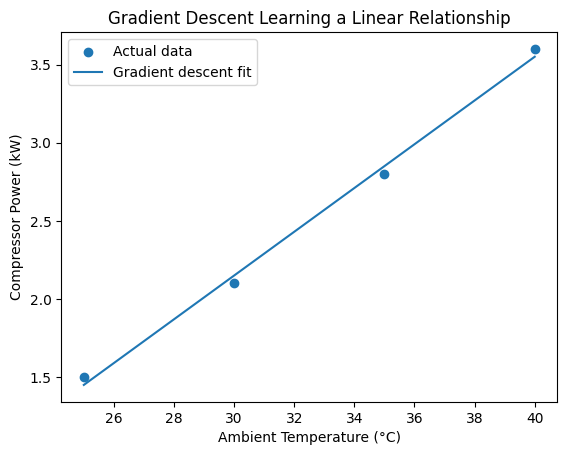

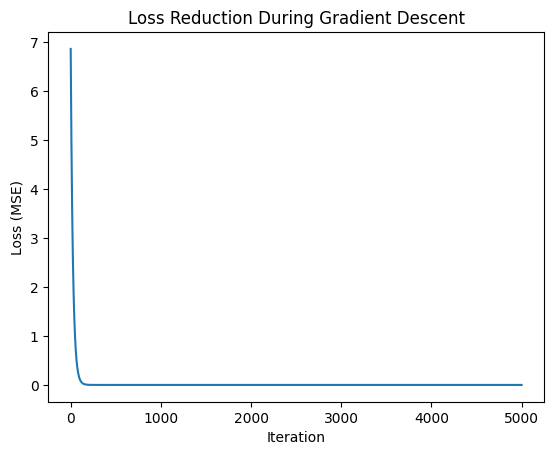

Learned slope on normalized x: 0.7826

Learned intercept: 2.5

Final loss: 0.0025

Two visualizations are important here:

1. The fitted line shows that the model has learned a reasonable relationship between ambient temperature and compressor power.

2. The loss curve shows how error decreases over time as the parameters improve.

This iterative improvement is what we call **learning**.

# 6. Key Takeaways

- Gradient descent is an optimization method used to learn model parameters.
- The model starts with an initial guess and improves step by step.
- The learning rate controls how aggressively the model updates itself.
- This process is very similar to engineering parameter tuning.

# 7. Try It Yourself

Experiment with the following values:

- `learning_rate = 0.001`
- `learning_rate = 0.1`
- `epochs = 500`
- `epochs = 20000`

Questions to think about:

- What happens when the learning rate is too small?
- What happens when it is too large?
- How many iterations are needed before the fit becomes stable?